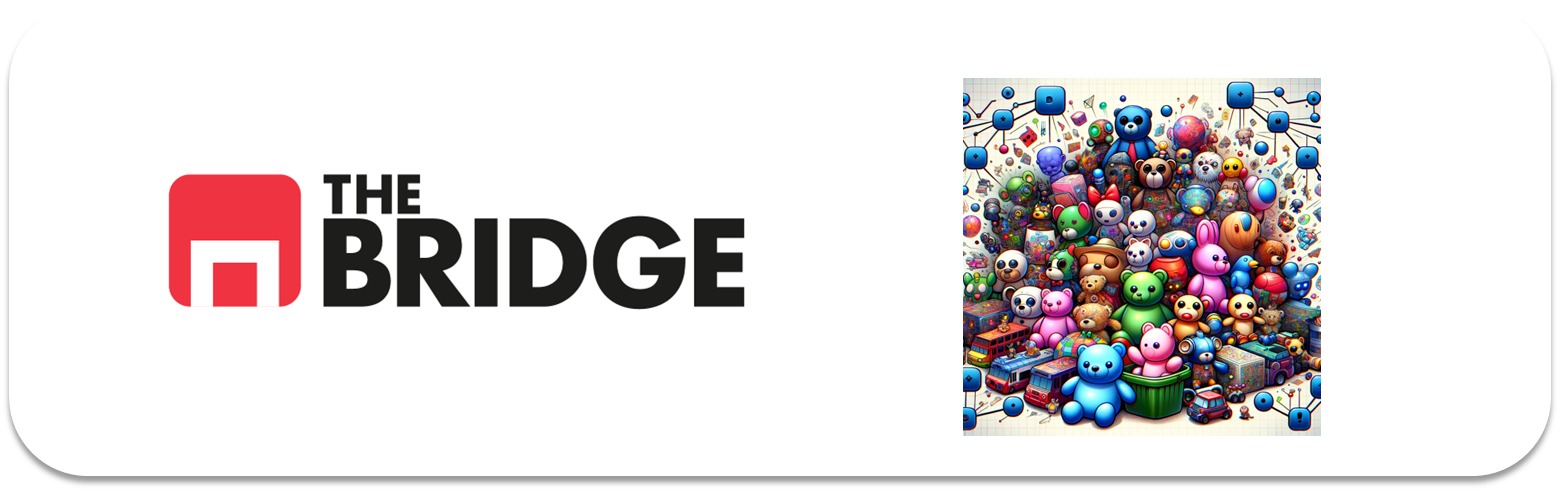

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_olivetti_faces

# Preprocesamiento y reducción de dimensionalidad
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans

# Métricas
from sklearn.metrics import silhouette_score

# División de datos
from sklearn.model_selection import train_test_split

# Modelo supervisado para comparación
from sklearn.ensemble import RandomForestClassifier

## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes en escala de grises de 64 × 64 píxeles de rostros.   


Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una feature y por cada imagen hay $64\times 64 = 4096$ features.  

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en el dataset.  

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en cada imagen, pero nosotros lo vamos a hacer de forma no supervisada. 



### #1.1


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [2]:
# Cargamos el dataset
olivetti = fetch_olivetti_faces()

# Mostramos su descripción
print(olivetti["DESCR"])

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\angel\scikit_learn_data
.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for s

### #1.2 

Aunque no lo vas a usar hasta el final de la práctica, muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [3]:
# Mostramos el target
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [4]:
# Creamos el DataFrame con los píxeles de las imágenes
df = pd.DataFrame(olivetti.data)

# Añadimos el target
df["target"] = olivetti.target

# Comprobamos el resultado
df.head()

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0


In [5]:
# Reordenamos aleatoriamente todas las filas
df_random = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Comprobamos el resultado
df_random.head()

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
2,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3
3,0.136364,0.140496,0.185950,0.280992,0.318182,0.363636,0.409091,0.417355,0.438017,0.454545,...,0.169421,0.206612,0.276859,0.355372,0.685950,0.661157,0.280992,0.371901,0.276859,21
4,0.652893,0.644628,0.652893,0.706612,0.714876,0.719008,0.743802,0.747934,0.747934,0.756198,...,0.074380,0.074380,0.082645,0.082645,0.111570,0.070248,0.086777,0.185950,0.231405,9


**Conclusión:**  
El dataset original estaba ordenado por persona, con 10 imágenes consecutivas para cada `target`. Tras aplicar `sample(frac=1)`, las 400 imágenes quedan reordenadas aleatoriamente, manteniendo la correspondencia entre los píxeles de cada imagen y su `target`.

### #1.3

Vamos a dividir en train y test, pero OJO RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es uan práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (80-10-10). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 90-10 y luego otro split 89-11 sobre el de 80 (para que de los números aproximados), por ejemplo.

* Aunque en un problema puramente no supervisado no es necesario realizar una división basada en el `target`, en esta práctica se realiza para poder comparar posteriormente los resultados del clustering con un modelo de clasificación.
* Dividimos los datos en tres conjuntos: 80% entrenamiento, 10% validación y 10% test, utilizando muestreo estratificado por `target`.

In [6]:
train_set, temp_set = train_test_split(
    df_random,
    test_size=0.20,
    stratify=df_random["target"],
    random_state=42
)

In [7]:
val_set, test_set = train_test_split(
    temp_set,
    test_size=0.50,
    stratify=temp_set["target"],
    random_state=42
)

In [8]:
print("Train:", train_set.shape)
print("Validación:", val_set.shape)
print("Test:", test_set.shape)

Train: (320, 4097)
Validación: (40, 4097)
Test: (40, 4097)


In [9]:
print("Train:")
print(train_set["target"].value_counts().sort_index())

print("\nValidación:")
print(val_set["target"].value_counts().sort_index())

print("\nTest:")
print(test_set["target"].value_counts().sort_index())

Train:
target
0     8
1     8
2     8
3     8
4     8
5     8
6     8
7     8
8     8
9     8
10    8
11    8
12    8
13    8
14    8
15    8
16    8
17    8
18    8
19    8
20    8
21    8
22    8
23    8
24    8
25    8
26    8
27    8
28    8
29    8
30    8
31    8
32    8
33    8
34    8
35    8
36    8
37    8
38    8
39    8
Name: count, dtype: int64

Validación:
target
0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    1
32    1
33    1
34    1
35    1
36    1
37    1
38    1
39    1
Name: count, dtype: int64

Test:
target
0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    1
32  

### #1.4

Crea los pares X,y para train, validation y test.

* Separamos las variables predictoras (`X`), correspondientes a los píxeles de las imágenes, y la variable objetivo (`y`), que identifica a cada persona, para los conjuntos de entrenamiento, validación y test.


In [ ]:

# Train
X_train = train_set.drop(columns="target")
y_train = train_set["target"]

# Validación
X_val = val_set.drop(columns="target")
y_val = val_set["target"]

# Test
X_test = test_set.drop(columns="target")
y_test = test_set["target"]

print("Train:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (320, 4096) (320,)
Validación: (40, 4096) (40,)
Test: (40, 4096) (40,)


Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

In [ ]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))

    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)

    plt.show()

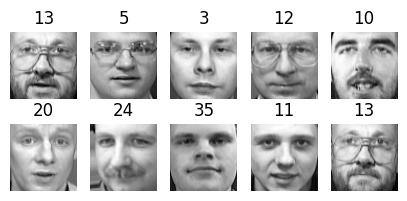

In [16]:
plot_faces(
    X_train.iloc[:10].values,
    y_train.iloc[:10].values
)

**Conclusión:**  
La visualización permite comprobar que cada observación corresponde a una imagen de 64 × 64 píxeles y que el `target` identifica a la persona representada. Una misma persona puede aparecer en distintas imágenes con pequeñas variaciones de expresión, posición o iluminación.

### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [18]:
pca = PCA(0.99)

X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(221)

In [19]:
print("Train PCA:", X_train_pca.shape)
print("Validación PCA:", X_val_pca.shape)
print("Test PCA:", X_test_pca.shape)

Train PCA: (320, 221)
Validación PCA: (40, 221)
Test PCA: (40, 221)


**Conclusión:**  
Mediante PCA se ha reducido la dimensionalidad de las imágenes de 4096 variables originales a 221 componentes principales, conservando el 99% de la varianza. Esta reducción permitirá trabajar con K-Means de forma más eficiente manteniendo prácticamente toda la información relevante de los datos.

### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas entre 0 y 1)

* Aplicamos K-Means sobre el conjunto de entrenamiento reducido mediante PCA y probamos diferentes valores de `k`, desde 5 hasta 150 en intervalos de 5.
* Para seleccionar el número óptimo de clusters utilizamos el `Silhouette Score`, buscando el valor de `k` que obtenga la puntuación más alta.

In [20]:
silhouette_scores = []

for k in range(5, 151, 5):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    labels = kmeans.fit_predict(X_train_pca)
    
    score = silhouette_score(X_train_pca, labels)
    
    silhouette_scores.append(score)
    
    print(f"k = {k} -> Silhouette Score = {score:.4f}")


k = 5 -> Silhouette Score = 0.1086
k = 10 -> Silhouette Score = 0.0918
k = 15 -> Silhouette Score = 0.0801
k = 20 -> Silhouette Score = 0.1034
k = 25 -> Silhouette Score = 0.1114
k = 30 -> Silhouette Score = 0.1248
k = 35 -> Silhouette Score = 0.1406
k = 40 -> Silhouette Score = 0.1508
k = 45 -> Silhouette Score = 0.1597
k = 50 -> Silhouette Score = 0.1710
k = 55 -> Silhouette Score = 0.1627
k = 60 -> Silhouette Score = 0.1730
k = 65 -> Silhouette Score = 0.1701
k = 70 -> Silhouette Score = 0.1699
k = 75 -> Silhouette Score = 0.1809
k = 80 -> Silhouette Score = 0.1851
k = 85 -> Silhouette Score = 0.1924
k = 90 -> Silhouette Score = 0.1860
k = 95 -> Silhouette Score = 0.1876
k = 100 -> Silhouette Score = 0.1921
k = 105 -> Silhouette Score = 0.1892
k = 110 -> Silhouette Score = 0.1913
k = 115 -> Silhouette Score = 0.1935
k = 120 -> Silhouette Score = 0.1931
k = 125 -> Silhouette Score = 0.1928
k = 130 -> Silhouette Score = 0.1941
k = 135 -> Silhouette Score = 0.1954
k = 140 -> Silhouette

In [21]:
k_values = list(range(5, 151, 5))

best_index = np.argmax(silhouette_scores)
best_k = k_values[best_index]
best_score = silhouette_scores[best_index]

print("Mejor k:", best_k)
print("Mejor Silhouette Score:", round(best_score, 4))

Mejor k: 150
Mejor Silhouette Score: 0.2013


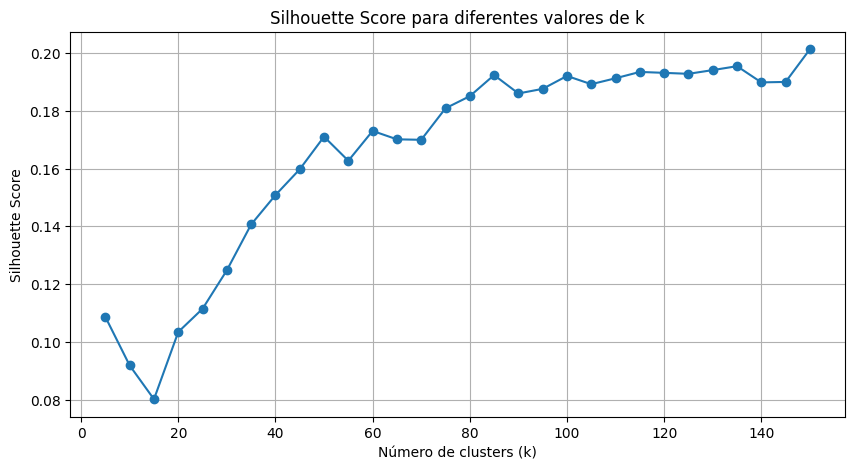

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score para diferentes valores de k")
plt.grid(True)

plt.show()

**Conclusión:**  
Tras evaluar valores de `k` entre 5 y 150 en intervalos de 5, el mayor Silhouette Score obtenido es **0.2013 para k = 150**. Por tanto, según este criterio, `k = 150` es el mejor valor dentro del rango analizado.

La gráfica muestra una tendencia general creciente del Silhouette Score, que se estabiliza aproximadamente a partir de valores de `k` cercanos a 85-100. Como el valor máximo se alcanza justo en el límite superior evaluado (`k = 150`), no podemos afirmar que sea el óptimo absoluto fuera del rango probado.

Además, el número de clusters obtenido no tiene por qué coincidir con las 40 personas reales del dataset, ya que K-Means realiza el agrupamiento sin utilizar las etiquetas (`target`).

### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

* Se aplica nuevamente K-Means sobre el conjunto de entrenamiento reducido mediante PCA, probando valores de `k` entre 5 y 150 en intervalos de 5.
* En este caso se utiliza la inercia para analizar el número adecuado de clusters mediante el método del codo.

In [ ]:
inertias = []

for k in range(5, 151, 5):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(X_train_pca)
    
    inertias.append(kmeans.inertia_)
    
    print(f"k = {k} -> Inercia = {kmeans.inertia_:.2f}")

k = 5 -> Inercia = 17034.63
k = 10 -> Inercia = 14948.45
k = 15 -> Inercia = 13973.87
k = 20 -> Inercia = 12499.55
k = 25 -> Inercia = 11590.90
k = 30 -> Inercia = 10677.71
k = 35 -> Inercia = 9852.67
k = 40 -> Inercia = 9141.87
k = 45 -> Inercia = 8523.20
k = 50 -> Inercia = 8007.92
k = 55 -> Inercia = 7773.29
k = 60 -> Inercia = 7251.33
k = 65 -> Inercia = 6929.94
k = 70 -> Inercia = 6670.21
k = 75 -> Inercia = 6228.45
k = 80 -> Inercia = 5865.90
k = 85 -> Inercia = 5548.37
k = 90 -> Inercia = 5332.62
k = 95 -> Inercia = 5119.63
k = 100 -> Inercia = 4832.76
k = 105 -> Inercia = 4649.01
k = 110 -> Inercia = 4405.13
k = 115 -> Inercia = 4154.64
k = 120 -> Inercia = 3959.35
k = 125 -> Inercia = 3747.08
k = 130 -> Inercia = 3524.58
k = 135 -> Inercia = 3359.88
k = 140 -> Inercia = 3206.10
k = 145 -> Inercia = 3025.66
k = 150 -> Inercia = 2761.41


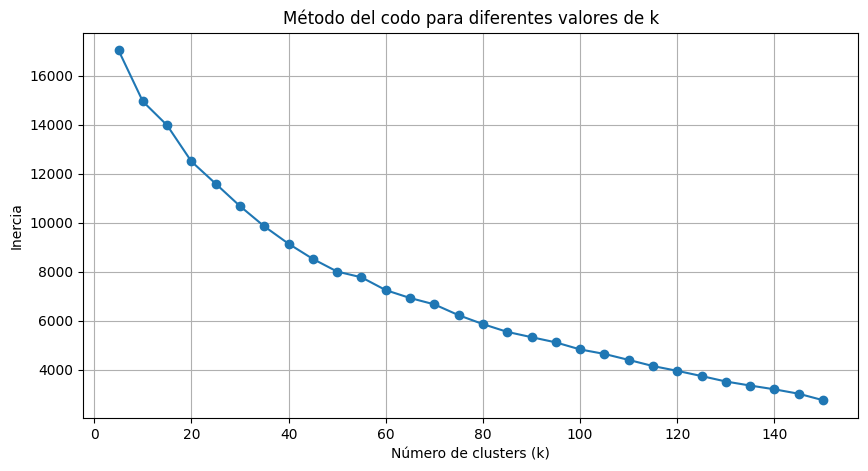

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para diferentes valores de k")
plt.grid(True)

plt.show()

**Conclusión:**  
La inercia disminuye progresivamente a medida que aumenta el número de clusters, como es esperable en K-Means. Sin embargo, la curva no presenta un punto de codo claramente definido.

Se observa que la reducción de la inercia comienza a suavizarse aproximadamente alrededor de valores de `k` entre 50 y 60, pero no existe un cambio de pendiente suficientemente marcado como para seleccionar un valor concreto con claridad.

Por tanto, el método del codo no refuerza de forma concluyente el resultado obtenido mediante Silhouette Score (`k = 150`). Ambos métodos muestran que la elección del número óptimo de clusters para este dataset no es evidente.

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

* Se crea el modelo K-Means utilizando el valor de `k` que obtuvo el mayor Silhouette Score en el ejercicio anterior.

In [25]:
best_model = KMeans(
    n_clusters=best_k,
    random_state=42
)

best_model.fit(X_train_pca)

best_model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",150
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?

* Se visualizan las imágenes pertenecientes a los 10 primeros clusters generados por el mejor modelo K-Means para comprobar si las caras agrupadas presentan similitudes visuales.

In [26]:
best_model.labels_

array([ 28, 118,  20, 141,  92,  64,  74,  41, 110,  42, 125,  70, 114,
        86, 117,   5,  76,  45,  11,  26,  63,  62,  40,  59,  35,  16,
        92,  24,  49,  28, 138,   2,  78,  15,  55,  97, 127,  78,  45,
        46,  84,  81, 134,  94,  33,  83,  69,  42,  55, 104, 115,  29,
        37,  90,  62,  63,  17,  86,   5, 119,   5, 127,  96,  27, 123,
        39,  43, 122,  82, 107,  77,  19, 128,  12,  82,  69,  51, 139,
       116,  37,  32,  74,  67, 144,   1,  10,  16,  21,  89,  94,  74,
       140,  92,  39,   7,  38, 109, 127,  13,  79,  32,  22,  99,  56,
        43, 149,  22, 101,   9, 102,  64,   4, 102,  50,  20,  72,  53,
        90,  52,   0, 105,  15,  10,  68,  21,  80,  69,  33,  87,  29,
       105,  49,  95,   3, 130,   0,  71,  60,  42,  15,  69,  74, 120,
         3,  25,  91, 101,  50,  69,  36,  47, 115,  37,  37,  19,   0,
        55,  51,  47,   3,  36,   6,  82,  25,  73, 131,  97,  19, 124,
       143, 100,  79,  26, 133,   0,  47,   4,  74, 115,  13,  7

Cluster 0 - 5 imágenes


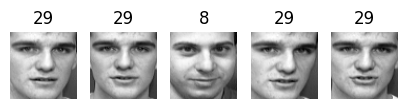

Cluster 1 - 5 imágenes


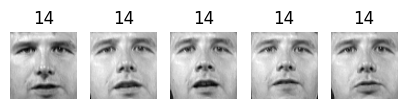

Cluster 2 - 2 imágenes


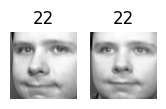

Cluster 3 - 3 imágenes


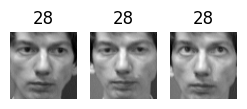

Cluster 4 - 2 imágenes


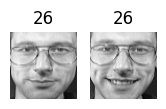

Cluster 5 - 4 imágenes


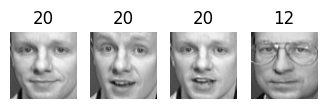

Cluster 6 - 1 imágenes


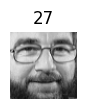

Cluster 7 - 3 imágenes


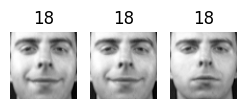

Cluster 8 - 3 imágenes


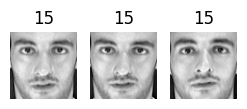

Cluster 9 - 2 imágenes


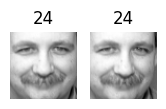

In [27]:
for cluster in range(10):
    
    indices = np.where(best_model.labels_ == cluster)[0]
    
    print(f"Cluster {cluster} - {len(indices)} imágenes")
    
    plot_faces(
        X_train.iloc[indices].values,
        y_train.iloc[indices].values
    )

**Conclusión:**  
La inspección visual muestra que K-Means consigue formar agrupaciones bastante coherentes. En varios de los primeros clusters todas las imágenes corresponden a la misma persona, como ocurre en los clusters 1, 2, 3, 4, 7, 8 y 9, a pesar de que el modelo no ha utilizado las etiquetas reales durante el entrenamiento.

Sin embargo, el agrupamiento no es perfecto. Por ejemplo, el cluster 0 contiene principalmente imágenes de la persona 29, pero también una de la persona 8, mientras que el cluster 5 mezcla imágenes de las personas 20 y 12.

Además, al utilizar `k = 150` sobre solo 320 imágenes se generan clusters muy pequeños, llegando incluso a aparecer clusters con una única imagen. Por tanto, aunque visualmente existen grupos de caras similares, el valor de `k` seleccionado mediante Silhouette Score produce una segmentación muy fragmentada.

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

* Se entrena un modelo supervisado `RandomForestClassifier` para predecir la persona representada en cada imagen. Se utilizan 150 estimadores, manteniendo el resto de hiperparámetros con sus valores por defecto, y se evalúa el modelo sobre el conjunto de validación.

In [28]:
rf = RandomForestClassifier(n_estimators=150)

rf.fit(X_train_pca, y_train)

val_score = rf.score(X_val_pca, y_val)

print(f"Accuracy en validación: {val_score:.4f}")

Accuracy en validación: 0.8500


**Conclusión:**  
El modelo `RandomForestClassifier` con 150 estimadores obtiene un **accuracy de 0.85 en el conjunto de validación**, clasificando correctamente 34 de las 40 imágenes.

El modelo utiliza las etiquetas reales durante el entrenamiento, por lo que se trata de un problema supervisado de clasificación, a diferencia de K-Means, que realizó las agrupaciones sin conocer la identidad de las personas.

### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

* Se utiliza el método `transform` del mejor modelo K-Means para representar cada imagen mediante sus distancias a los centroides. Posteriormente, se entrena un nuevo `RandomForestClassifier` sobre estas nuevas features y se evalúa sobre el conjunto de validación.

In [29]:
X_train_reduced = best_model.transform(X_train_pca)
X_val_reduced = best_model.transform(X_val_pca)
X_test_reduced = best_model.transform(X_test_pca)

print("Train:", X_train_reduced.shape)
print("Validación:", X_val_reduced.shape)
print("Test:", X_test_reduced.shape)

Train: (320, 150)
Validación: (40, 150)
Test: (40, 150)


In [30]:
rf_reduced = RandomForestClassifier(n_estimators=150)

rf_reduced.fit(X_train_reduced, y_train)

val_score_reduced = rf_reduced.score(X_val_reduced, y_val)

print(f"Accuracy en validación: {val_score_reduced:.4f}")

Accuracy en validación: 0.8000


**Conclusión:**  
Al utilizar K-Means como método de transformación, las 221 componentes obtenidas mediante PCA se reducen a 150 nuevas features, correspondientes a las distancias de cada imagen a los 150 centroides.

El Random Forest entrenado con estas nuevas variables obtiene un **accuracy de 0.80 en validación**, clasificando correctamente 32 de las 40 imágenes. Este resultado es ligeramente inferior al **0.85** obtenido anteriormente utilizando directamente las componentes de PCA.

Por tanto, en este caso la transformación mediante K-Means permite reducir aún más la dimensionalidad, aunque supone una pequeña pérdida de rendimiento en la clasificación.

### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus distancias a los centroides sean las features de un clasificador RandomForest y que permita al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos de Accuracy)

* Se prueban diferentes valores de `k` para K-Means. Para cada valor se transforman los datos en las distancias a los centroides y se entrena un `RandomForestClassifier`.
El mejor valor de `k` será aquel que permita obtener el mayor `accuracy` sobre el conjunto de validación.

In [31]:
k_values_rf = list(range(5, 151, 5))
accuracy_scores = []

for k in k_values_rf:
    
    # Entrenar K-Means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    kmeans.fit(X_train_pca)
    
    # Transformar los datos en distancias a los centroides
    X_train_kmeans = kmeans.transform(X_train_pca)
    X_val_kmeans = kmeans.transform(X_val_pca)
    
    # Entrenar Random Forest
    rf_kmeans = RandomForestClassifier(
        n_estimators=150,
        random_state=42
    )
    
    rf_kmeans.fit(X_train_kmeans, y_train)
    
    # Evaluar en validación
    accuracy = rf_kmeans.score(X_val_kmeans, y_val)
    accuracy_scores.append(accuracy)
    
    print(f"k = {k} -> Accuracy = {accuracy:.4f}")

k = 5 -> Accuracy = 0.4000
k = 10 -> Accuracy = 0.5750
k = 15 -> Accuracy = 0.5500
k = 20 -> Accuracy = 0.6250
k = 25 -> Accuracy = 0.7000
k = 30 -> Accuracy = 0.7500
k = 35 -> Accuracy = 0.7750
k = 40 -> Accuracy = 0.8250
k = 45 -> Accuracy = 0.8000
k = 50 -> Accuracy = 0.8000
k = 55 -> Accuracy = 0.7500
k = 60 -> Accuracy = 0.7750
k = 65 -> Accuracy = 0.7750
k = 70 -> Accuracy = 0.7750
k = 75 -> Accuracy = 0.8000
k = 80 -> Accuracy = 0.7750
k = 85 -> Accuracy = 0.8000
k = 90 -> Accuracy = 0.8000
k = 95 -> Accuracy = 0.8000
k = 100 -> Accuracy = 0.7750
k = 105 -> Accuracy = 0.7500
k = 110 -> Accuracy = 0.7750
k = 115 -> Accuracy = 0.8000
k = 120 -> Accuracy = 0.8000
k = 125 -> Accuracy = 0.7750
k = 130 -> Accuracy = 0.7500
k = 135 -> Accuracy = 0.7750
k = 140 -> Accuracy = 0.7500
k = 145 -> Accuracy = 0.7500
k = 150 -> Accuracy = 0.7750


In [32]:
best_index_rf = np.argmax(accuracy_scores)

best_k_rf = k_values_rf[best_index_rf]
best_accuracy_rf = accuracy_scores[best_index_rf]

print("Mejor k:", best_k_rf)
print("Mejor Accuracy:", round(best_accuracy_rf, 4))

Mejor k: 40
Mejor Accuracy: 0.825


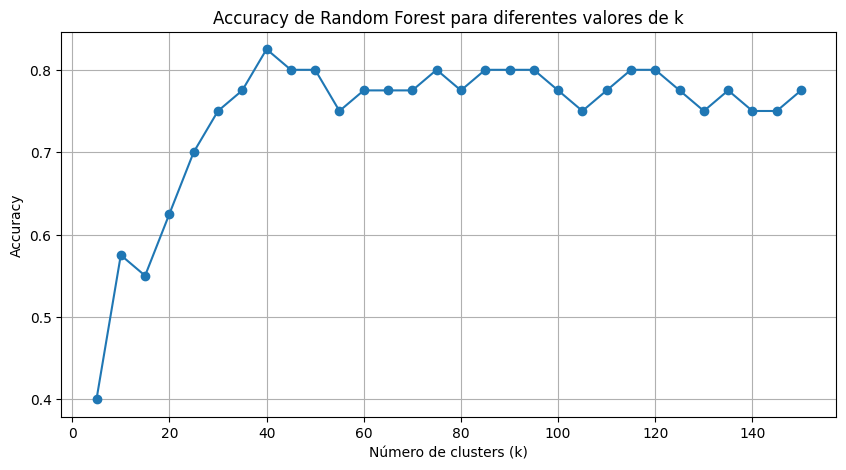

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(k_values_rf, accuracy_scores, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Accuracy")
plt.title("Accuracy de Random Forest para diferentes valores de k")
plt.grid(True)

plt.show()

**Conclusión:**  
Tras probar diferentes valores de `k`, el mejor rendimiento se obtiene con **k = 40**, alcanzando un **accuracy de 0.825** en el conjunto de validación, equivalente a 33 de las 40 imágenes correctamente clasificadas.

Este resultado mejora el accuracy de 0.80 obtenido anteriormente con `k = 150`. Además, resulta interesante que el mejor valor encontrado sea 40, coincidiendo con el número de personas presentes en el dataset, aunque esto no implica necesariamente que cada cluster represente de forma exacta a una persona.

La transformación mediante K-Means con `k = 40` permite representar cada imagen mediante únicamente 40 distancias a centroides y mantener un rendimiento cercano al 0.85 obtenido por Random Forest utilizando las 221 componentes de PCA.